In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# to show the visualizations in this file itself
%matplotlib inline

In [4]:
df = pd.read_csv('weight-height.csv')

In [9]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


Text(0.5, 1.0, 'Weight vs Height')

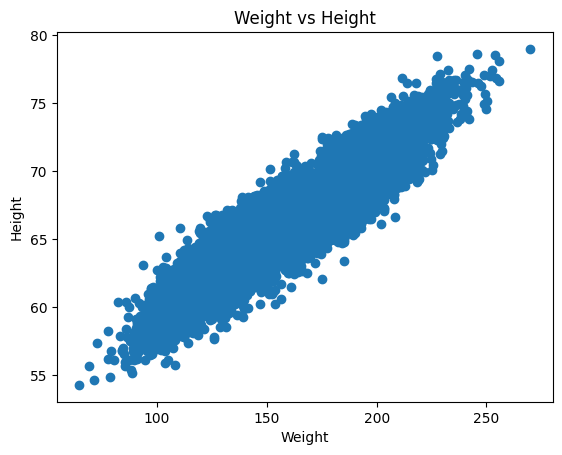

In [5]:
#Scatter Plot

plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')

In [6]:
df.drop('Gender', axis=1, inplace=True)

In [7]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [8]:
#Correlation
df.corr()

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


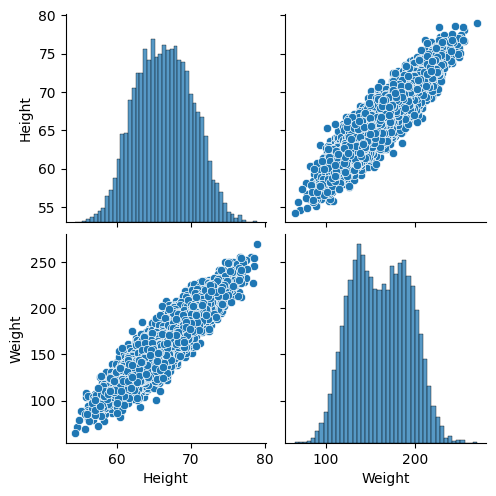

In [9]:
#Seaborn

import seaborn as sns
sns.pairplot(df)

In [25]:
#Independent and dependent features

X = df[['Weight']]    #independent feature should be a Dataframe and not Series

Y = df['Height']       #dependent feature may be a Dataframe or Series

In [12]:
#Train Test split

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)  #randomstate is given so that the same randomness can be maintained with sir!

In [17]:
X_train.shape

(7500, 1)

In [26]:
X_test.shape

(2500, 1)

In [27]:
Y_test.shape

(2500,)

In [13]:
#Standardization
#this is needed so that Global minima can be reached faster by bigger values of independent feature
#Zscore is applied to all data points so that they al hv mean=0 & std dev.=1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()       #z = (x- mu)/std dev
X_train = scaler.fit_transform(X_train)   #all data points are assigned with the above formula ,i.e, standardized


In [14]:
X_test = scaler.transform(X_test)   #only transform is used here because we dont want to use the mean or dev. of test data


In [15]:
#Apply Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)    #n_jobs utilizes all the processors
regression.fit(X_train, Y_train)

LinearRegression(n_jobs=-1)

In [16]:
print("Coefficient or Slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or Slope: [3.5520765]
Intercept: 66.3483476614904


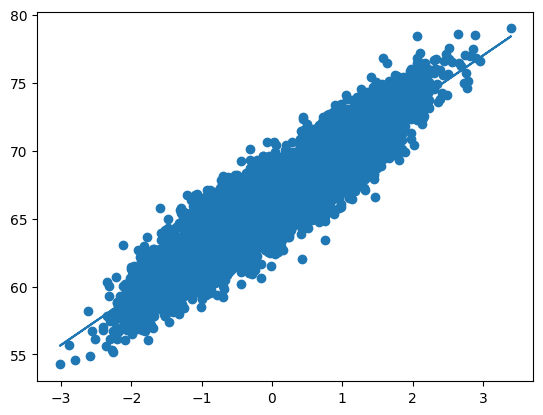

In [17]:
#Plot Training Data plot best fit line
plt.scatter(X_train, Y_train)
plt.plot(X_train,regression.predict(X_train))     #creates the best fit line with true values and predicted values along the line

#Prediction of test Data
1. predicted ht o/p = intercept +coeff*(weights)
2. Y_pred = 66.348 + 3.55(X_test)

In [18]:
#Prediction for test data
Y_pred = regression.predict(X_test)

In [19]:
#Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.1245002931661268
1.1618686241177074
1.4575665656038241


#R2-Score
R^2 = 1 - SSres/SStotal

In [20]:
from sklearn.metrics import r2_score
score = r2_score(Y_test, Y_pred)
print(score)

0.8574288811012989


Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]

In [28]:
adj_r2 = 1 - ((1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))
print(adj_r2)

0.8573718069944539


In [29]:
#OLS Linear Regression

import statsmodels.api as sm
model = sm.OLS(Y_train, X_train).fit()      #model is fit using OLS library
prediction = model.predict(X_test)
print(prediction)

[ 1.3183849   3.7639285   0.99687554 ... -4.1451931   0.45415466
  0.20823876]


In [30]:
print(model.summary())      #we see that ols gives same values as gradient descent method

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.003
Model:                            OLS   Adj. R-squared (uncentered):              0.003
Method:                 Least Squares   F-statistic:                              21.48
Date:                Tue, 13 May 2025   Prob (F-statistic):                    3.63e-06
Time:                        12:08:37   Log-Likelihood:                         -42106.
No. Observations:                7500   AIC:                                  8.421e+04
Df Residuals:                    7499   BIC:                                  8.422e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [36]:
#Prediction for new data

#scaling needs to be done so that we get correct value
#scaling needs to be done only  for selected algorithms
regression.predict(scaler.transform([[567]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([111.35950794])